In [2]:
import pandas as pd

In [7]:
df_klines

,open_time,open,high,low,close,volume,turnover
0,2020-03-01,6500.0,6838.0,5841.5,6405.0,52238.985,334590698.9250000119
1,2020-04-01,6405.0,9458.0,6145.0,8625.0,532029.546,4588754834.25
2,2020-05-01,8625.0,10059.5,8153.0,9449.5,603928.977,5706826868.1614999771
3,2020-06-01,9449.5,10352.0,8840.0,9135.5,239068.501,2184010290.8825764656
4,2020-07-01,9135.5,11443.5,8910.0,11339.0,296758.679,3364946661.1760106087
...,...,...,...,...,...,...,...
69,2025-12-01,90308.6,94550.0,83755.3,87594.9,2144461.134,190923535887.6138
70,2026-01-01,87594.9,97963.2,75689.6,78704.4,1978507.650,177568659081.9619
71,2026-02-01,78704.4,79388.5,59888.0,66939.6,2823008.760,194016021090.2396
72,2026-03-01,66939.6,76053.9,64935.7,68244.6,2728909.402,190310143313.6103


In [9]:
from data_loader import DataLoader
import os
import time
import logging
import traceback
from dotenv import load_dotenv
from binance.um_futures import UMFutures
load_dotenv()
from pybit.unified_trading import HTTP as BybitHTTP 
key = os.getenv('BYBIT_API_KEY')
secret = os.getenv('BYBIT_SECRET_KEY')

client = UMFutures(key=key, secret=secret)
bybit_client = BybitHTTP(api_key=key, api_secret=secret)
loader = DataLoader(client, bybit_client=bybit_client)
df_klines = loader.get_bybit_klines(symbol="BTCUSDT", interval="1", limit=1500)

if df_klines is not None:
    df_klines["open_time"] = pd.to_datetime(df_klines["open_time"], unit="ms")
    
    print(f"成功獲取 {len(df_klines)} 筆數據！")
    print("資料前 5 筆預覽：")
    print(df_klines.head())
    
    # 將數據儲存為 CSV 檔案
    filename = "BTCUSDT_futures_1m2.csv"
    df_klines.to_csv(filename, index=False)
    print(f"\n數據已成功儲存至檔案：{filename}")

成功獲取 1000 筆數據！
資料前 5 筆預覽：
            open_time     open     high      low    close  volume  \
0 2026-04-22 19:42:00  78797.0  78818.4  78768.5  78780.7  31.245   
1 2026-04-22 19:43:00  78780.7  78811.1  78780.7  78811.0  17.605   
2 2026-04-22 19:44:00  78811.0  78827.0  78807.5  78809.4  15.902   
3 2026-04-22 19:45:00  78809.4  78809.4  78764.1  78787.7  18.791   
4 2026-04-22 19:46:00  78787.7  78798.3  78759.0  78781.5  11.336   

       turnover  
0  2461917.3618  
1  1387284.3683  
2  1253360.0368  
3  1480429.5204  
4   893075.7505  

數據已成功儲存至檔案：BTCUSDT_futures_1m2.csv


In [10]:
tw=loader.get_bybit_orderbook_depth(symbol="BTCUSDT")

In [11]:
tw

,timestamp,level,bid_price,bid_qty,ask_price,ask_qty
0,1776946897843,1,77582.1,1.844,77582.2,3.098
1,1776946897843,2,77582.0,0.001,77582.3,0.001
2,1776946897843,3,77581.3,0.020,77582.4,0.001
3,1776946897843,4,77580.8,0.001,77582.8,0.001
4,1776946897843,5,77580.7,0.004,77582.9,0.101


In [2]:
from utils.database import DatabaseHandler
from utils.data_filler import DataGapFiller
from utils.database import DatabaseHandler
from data_loader import DataLoader
import os
from binance.um_futures import UMFutures
TARGET_SOURCE = "binance"     # 填寫 "binance"或 "bybit"
TARGET_SYMBOL = "BTCUSDT"     # 交易對名稱
TARGET_INTERVAL = "1m"        # K線週期 (1m, 5m, 15m, 1h, 1d)
START_TIME = "2025-03-29 00:00:00" # 起始時間 (格式: YYYY-MM-DD HH:MM:SS)
END_TIME   = "2026-03-29 00:00:00" # 結束時間 (格式: YYYY-MM-DD HH:MM:SS)

#
key = os.getenv('BINANCE_API_KEY')
secret = os.getenv('BINANCE_SECRET_KEY')
client = UMFutures(key=key, secret=secret)

loader = DataLoader(client=client)
fetch_function = loader.get_binance_klines
source=TARGET_SOURCE
symbol=TARGET_SYMBOL
interval=TARGET_INTERVAL
start_time=START_TIME
end_time=END_TIME

api_limit=1000
target_db_symbol=symbol
fetch_function=loader.get_binance_klines
db = DatabaseHandler()
filler = DataGapFiller(
        db_handler=db,
        fetch_func=fetch_function,
        symbol=symbol,               # 'BTCUSDT'
        db_symbol=target_db_symbol,  # 'BYBIT_BTCUSDT'
        interval=interval,
        api_limit=api_limit
    )

filler.only_check_data(start_date=start_time, end_date=end_time)

僅檢查 BTCUSDT (1m) 從 2025-03-29 00:00:00 到 2026-03-29 00:00:00 的資料...
資料庫資料完整，無缺失區塊！



In [3]:
interval = "1m"
interval[:-1]

'1'

In [5]:
from pybit.unified_trading import HTTP
import pandas as pd
def test_bybit_historical_kline():
    # 1. 初始化 Bybit Client (公開數據不需要 API Key)
    client = HTTP(testnet=False)

    # 2. 設定剛才填補迴圈中的第一個區塊參數
    symbol = "BTCUSDT"
    interval = "1"  # Bybit 的 1m 是 "1"
    limit = 1000

    # 測試區塊: 2025-03-29 00:00:00 到 2025-03-29 16:39:00 (大約1000分鐘)
    start_time_str = "2025-03-29 00:00:00"
    end_time_str   = "2025-03-29 16:39:00"

    # 轉換成毫秒時間戳 (強制轉為 int)
    start_ts = int(pd.to_datetime(start_time_str).timestamp() * 1000)
    end_ts   = int(pd.to_datetime(end_time_str).timestamp() * 1000)

    print(f"=== 開始測試 Bybit API ===")
    print(f"交易對: {symbol}, 週期: {interval}m, Limit: {limit}")
    print(f"請求區間: {start_time_str} ({start_ts}) -> {end_time_str} ({end_ts})\n")

    try:
        # 3. 直接呼叫 Bybit V5 API
        response = client.get_kline(
            category="linear",
            symbol=symbol,
            interval=interval,
            start=start_ts,
            end=end_ts,
            limit=limit
        )
        
        # 4. 解析 API 的真實回應
        ret_code = response.get('retCode')
        ret_msg = response.get('retMsg')
        print(f"API 回傳狀態碼: {ret_code}")
        print(f"API 系統訊息: {ret_msg}")
        
        if ret_code != 0:
            print("❌ API 拒絕了請求，請看上面的錯誤訊息！")
            return

        klines = response.get('result', {}).get('list', [])
        print(f"✅ 成功取得 K 線數量: {len(klines)} 筆")
        
        if klines:
            # Bybit 回傳預設是由新到舊，[0] 是最新的一根，[-1] 是最舊的一根
            print(f"  └ 最新一筆時間: {pd.to_datetime(int(klines[0][0]), unit='ms')}")
            print(f"  └ 最舊一筆時間: {pd.to_datetime(int(klines[-1][0]), unit='ms')}")
        else:
            print("⚠️ API 狀態碼成功，但回傳的資料列是空的 (可能該時段沒資料，或查太遠了)！")
            
    except Exception as e:
        print(f"❌ 發生嚴重錯誤 (通常是參數格式不對): {e}")

if __name__ == "__main__":
    test_bybit_historical_kline()

=== 開始測試 Bybit API ===
交易對: BTCUSDT, 週期: 1m, Limit: 1000
請求區間: 2025-03-29 00:00:00 (1743206400000) -> 2025-03-29 16:39:00 (1743266340000)

API 回傳狀態碼: 0
API 系統訊息: OK
✅ 成功取得 K 線數量: 1000 筆
  └ 最新一筆時間: 2025-03-29 16:39:00
  └ 最舊一筆時間: 2025-03-29 00:00:00


In [11]:
from data_sources.bybit_source import BybitExternalSource
bybit_source = BybitExternalSource()

symbol = "BTCUSDT"
interval = "1"  # Bybit 的 1m 是 "1"
limit = 1000
start_ts = "2025-03-29 00:00:00"
end_ts   = "2025-03-29 16:39:00"

df_new = bybit_source.get_klines(
                symbol=symbol, 
                interval=interval, 
                limit=limit,
                startTime=start_ts,
                endTime=end_ts
            )

Bybit K線抓取失敗: invalid literal for int() with base 10: '2025-03-29 00:00:00'


In [10]:
df_new 

,open_time,open,high,low,close,volume,turnover
0,1743206400000,84375.0,84382.9,84336.4,84336.5,25.077,2115784.5022
1,1743206460000,84336.5,84336.5,84320.0,84320.0,8.634,728077.6344
2,1743206520000,84320.0,84342.4,84316.7,84337.0,10.955,923794.6973
3,1743206580000,84337.0,84350.0,84323.6,84323.6,11.171,942035.5395
4,1743206640000,84323.6,84323.6,84316.7,84316.8,7.470,629867.1711
...,...,...,...,...,...,...,...
995,1743266100000,82382.5,82406.0,82370.1,82370.1,13.709,1129414.3266
996,1743266160000,82370.1,82387.7,82370.1,82387.7,7.610,626904.7257
997,1743266220000,82387.7,82403.5,82387.6,82403.5,11.575,953725.6918
998,1743266280000,82403.5,82413.4,82386.8,82397.2,11.451,943595.2312


In [15]:
import pandas as pd
import zipfile

# 替換成您剛剛跑出錯誤的那個檔案的完整路徑
file_path = "./bybit_raw_data/2026-03-19_BTCUSDT_ob200.data.zip"

try:
    with zipfile.ZipFile(file_path, 'r') as z:
        target_filename = z.namelist()[0]
        with z.open(target_filename) as f:
            # nrows=0 代表只讀取標題列，不載入龐大的資料體
            df = pd.read_csv(f, nrows=0)
            print("✅ 成功讀取檔案！")
            print("檔案內真實的欄位名稱為:", df.columns.tolist())
except Exception as e:
    print(f"讀取失敗: {e}")

✅ 成功讀取檔案！
檔案內真實的欄位名稱為: ['{"topic":"orderbook.200.BTCUSDT"', 'type:"snapshot"', 'ts:1773878401390', 'data:{"s":"BTCUSDT"', 'b:[["71204.10"', '3.326]', '["71204.00"', '0.160]', '["71203.60"', '0.003]', '["71202.50"', '0.001]', '["71202.40"', '0.001].1', '["71202.00"', '0.108]', '["71201.90"', '0.317]', '["71201.80"', '0.001].2', '["71201.70"', '0.001].3', '["71201.40"', '0.001].4', '["71201.20"', '0.003].1', '["71200.90"', '0.004]', '["71200.80"', '0.036]', '["71200.70"', '0.001].5', '["71200.50"', '0.075]', '["71200.40"', '0.001].6', '["71200.20"', '0.299]', '["71200.00"', '0.389]', '["71199.30"', '0.001].7', '["71199.00"', '0.008]', '["71198.80"', '0.299].1', '["71198.70"', '0.002]', '["71198.40"', '0.001].8', '["71198.30"', '0.298]', '["71198.00"', '0.001].9', '["71197.90"', '0.003].2', '["71197.80"', '0.001].10', '["71197.70"', '0.011]', '["71197.30"', '0.142]', '["71197.20"', '1.179]', '["71197.10"', '0.012]', '["71197.00"', '0.049]', '["71196.60"', '0.001].11', '["71196.50"', '0.28

In [ ]:
import os
import glob
import json
import pandas as pd
import zipfile

def extract_top5_from_bybit_jsonlines_safe(folder_path, output_csv="processed_l2_top5.csv"):
    file_pattern = os.path.join(folder_path, "*.zip")
    file_list = glob.glob(file_pattern)
    
    if not file_list:
        print(f"在 {folder_path} 找不到任何 .zip 壓縮檔！")
        return
        
    print(f"找到 {len(file_list)} 個壓縮檔，準備使用【低記憶體安全模式】處理...")
    
    # 執行前先刪除舊的同名檔案，避免重複接續寫入
    if os.path.exists(output_csv):
        os.remove(output_csv)
        
    total_rows = 0
    
    for idx, file_path in enumerate(file_list):
        print(f"[{idx+1}/{len(file_list)}] 處理中: {os.path.basename(file_path)}")
        parsed_data = [] 
        
        try:
            with zipfile.ZipFile(file_path, 'r') as z:
                target_filename = z.namelist()[0]
                with z.open(target_filename) as f:
                    for line in f:
                        line_str = line.decode('utf-8').strip()
                        if not line_str: continue
                        
                        try:
                            record = json.loads(line_str)
                        except:
                            continue
                            
                        ts = record.get('ts')
                        bids = record.get('data', {}).get('b', [])
                        asks = record.get('data', {}).get('a', [])
                        
                        if not ts or (not bids and not asks): continue
                            
                        row = {'timestamp': int(ts)}
                        for i in range(5):
                            level = i + 1
                            row[f'bid_price_{level}'] = float(bids[i][0]) if len(bids) > i else None
                            row[f'bid_qty_{level}']   = float(bids[i][1]) if len(bids) > i else None
                            row[f'ask_price_{level}'] = float(asks[i][0]) if len(asks) > i else None
                            row[f'ask_qty_{level}']   = float(asks[i][1]) if len(asks) > i else None
                        parsed_data.append(row)
            
            if parsed_data:
                df = pd.DataFrame(parsed_data)
                
                # ==========================================
                # 【關鍵修改】處理完一天，立刻寫入 CSV！
                # ==========================================
                # 如果是第一天 (total_rows == 0)，就寫入欄位名稱 (header=True)
                # 如果是第二天之後，就不寫入欄位名稱 (header=False)，並且用 mode='a' 接在檔案後面
                write_header = (total_rows == 0)
                df.to_csv(output_csv, mode='a', index=False, header=write_header)
                
                total_rows += len(df)
                print(f"  └─ 成功寫入 {len(df)} 筆。 (累積: {total_rows} 筆)\n")
                
                # 釋放記憶體
                del df 
                del parsed_data
                
        except Exception as e:
            print(f"發生錯誤: {e}\n")

    print(f" 任務大功告成！共計寫入 {total_rows} 筆資料至 {output_csv}")

if __name__ == "__main__":
    TARGET_FOLDER = "./bybit_raw_data" 
    extract_top5_from_bybit_jsonlines_safe(folder_path=TARGET_FOLDER)

找到 1 個壓縮檔，開始處理...
[1/1] 正在處理: 2026-03-19_BTCUSDT_ob200.data.zip
  └─ 成功提取 863864 筆快照。

正在合併所有日期的資料...
處理完成！結果已儲存至: processed_l2_top5.csv

=== 這是其中一筆轉換後的 Top 5 L2 資料 ===
timestamp      : 1773878401390.0
bid_price_1    : 71204.1
bid_qty_1      : 3.326
ask_price_1    : 71204.2
ask_qty_1      : 2.339
bid_price_2    : 71204.0
bid_qty_2      : 0.16
ask_price_2    : 71204.4
ask_qty_2      : 0.001
bid_price_3    : 71203.6
bid_qty_3      : 0.003
ask_price_3    : 71204.7
ask_qty_3      : 0.001
bid_price_4    : 71202.5
bid_qty_4      : 0.001
ask_price_4    : 71205.1
ask_qty_4      : 0.001
bid_price_5    : 71202.4
bid_qty_5      : 0.001
ask_price_5    : 71205.2
ask_qty_5      : 0.001


正在讀取資料 (為保持流暢，僅抽取最後 3000 筆)...


C:\Users\User\AppData\Local\Temp\ipykernel_47988\204950850.py:98: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_47988\204950850.py:98: UserWarning: Glyph 30436 (\N{CJK UNIFIED IDEOGRAPH-76E4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_47988\204950850.py:98: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_47988\204950850.py:98: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_47988\204950850.py:98: UserWarning: Glyph 36067 (\N{CJK UNIFIED IDEOGRAPH-8CE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_47988\204950850.py:101: UserWarning: Glyph 36023 (\N{CJK UNIFI

圖表已儲存為 orderbook_analysis.png


d:\investment\bicintive\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36023 (\N{CJK UNIFIED IDEOGRAPH-8CB7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\investment\bicintive\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30436 (\N{CJK UNIFIED IDEOGRAPH-76E4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\investment\bicintive\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\investment\bicintive\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\investment\bicintive\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36067 (\N{CJK UNIFIED IDEOGRAPH-8CE3}) missin

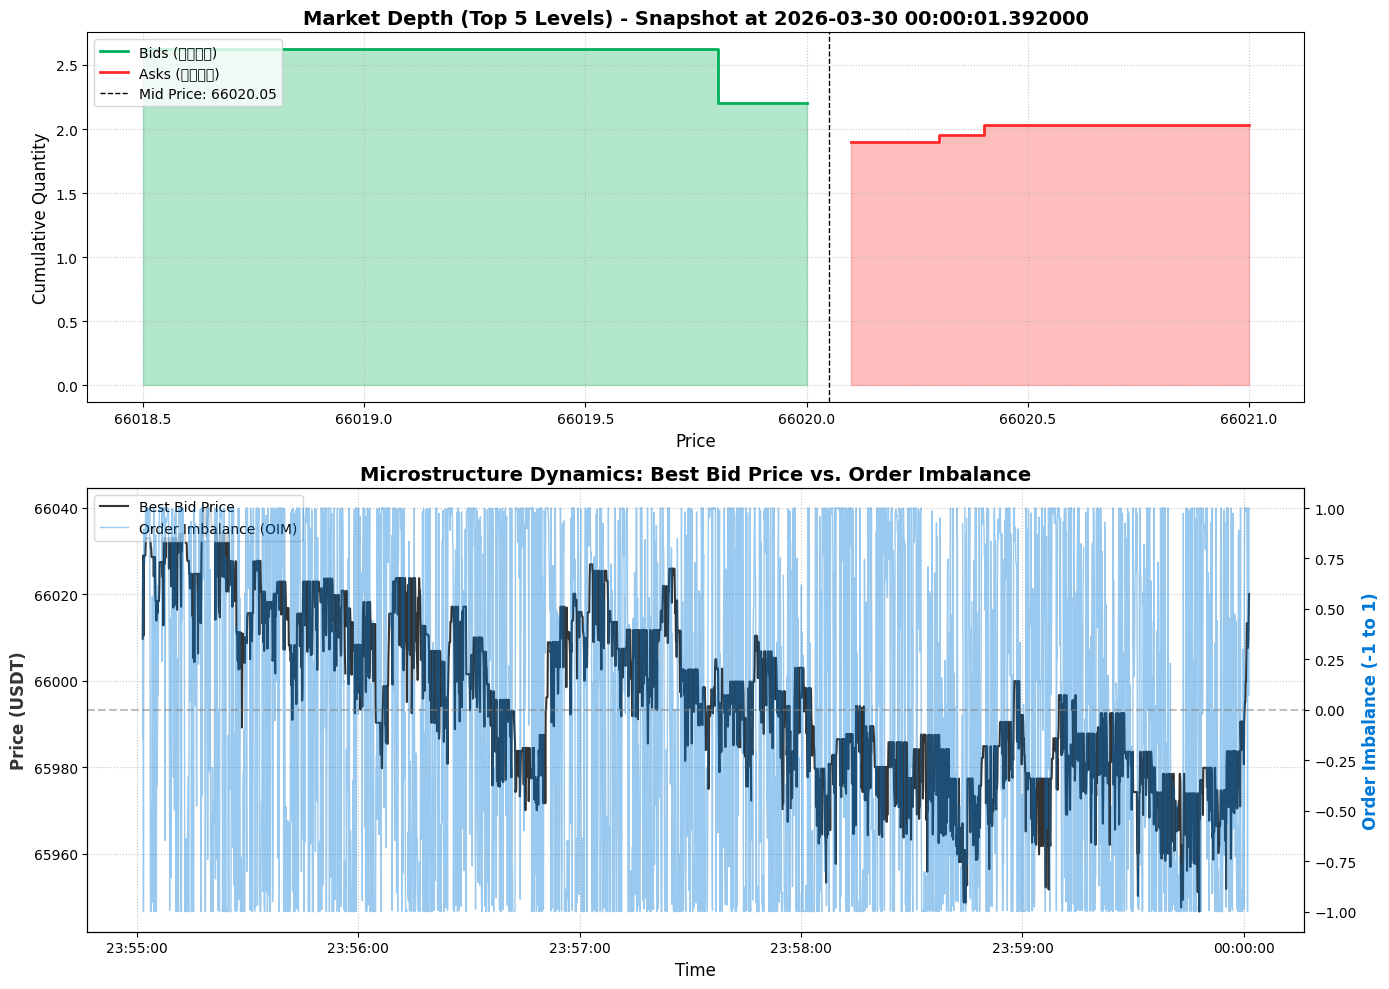

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def visualize_orderbook(csv_path="processed_l2_top5.csv", sample_size=5000):
    """
    讀取 L2 數據並畫出：
    1. 最新一筆快照的「市場深度圖 (Market Depth)」
    2. 過去 N 筆的「價格走勢與訂單不平衡率 (OIM)」
    """
    print(f"正在讀取資料 (為保持流暢，僅抽取最後 {sample_size} 筆)...")
    
    # 由於檔案可能很大，我們利用 Pandas 讀取最後 N 筆資料
    # 先讀取少數幾行來獲取總行數或直接使用 tail 的概念
    # 這裡為求穩定，我們先讀取結尾區塊 (假設檔案大小容許，若太大建議用 tail 指令先切分)
    try:
        # 如果檔案太大，這行可能會慢，實務上可改用 chunk 讀取最後一塊
        df = pd.read_csv(csv_path) 
        if len(df) > sample_size:
            df = df.tail(sample_size).copy()
    except Exception as e:
        print(f"讀檔失敗: {e}")
        return

    # 轉換時間戳為可讀時間
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
    
    # 計算 Level 1 的 Order Imbalance (OIM)
    df['OIM'] = (df['bid_qty_1'] - df['ask_qty_1']) / (df['bid_qty_1'] + df['ask_qty_1'])

    # 建立 2x1 的上下兩張圖表
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1.2]})
    
    # ==========================================
    # 圖表一：市場深度圖 (Market Depth Snapshot)
    # ==========================================
    latest = df.iloc[-1] # 取最後一筆 (最新) 快照
    
    # 整理買單 (Bids) - 價格由高到低，我們將其反轉為由低到高以符合 X 軸
    bids_price = [latest[f'bid_price_{i}'] for i in range(1, 6)][::-1]
    bids_qty = [latest[f'bid_qty_{i}'] for i in range(1, 6)][::-1]
    # 累計深度 (從最靠近市價的 Level 1 開始累加)
    bids_cum_qty = np.cumsum([latest[f'bid_qty_{i}'] for i in range(1, 6)])[::-1]

    # 整理賣單 (Asks) - 價格由低到高
    asks_price = [latest[f'ask_price_{i}'] for i in range(1, 6)]
    asks_qty = [latest[f'ask_qty_{i}'] for i in range(1, 6)]
    # 累計深度
    asks_cum_qty = np.cumsum(asks_qty)

    # 繪製買單綠色階梯圖
    ax1.step(bids_price, bids_cum_qty, color='#00b159', where='pre', linewidth=2, label='Bids (買盤深度)')
    ax1.fill_between(bids_price, bids_cum_qty, color='#00b159', alpha=0.3, step='pre')

    # 繪製賣單紅色階梯圖
    ax1.step(asks_price, asks_cum_qty, color='#ff2a2a', where='post', linewidth=2, label='Asks (賣盤深度)')
    ax1.fill_between(asks_price, asks_cum_qty, color='#ff2a2a', alpha=0.3, step='post')

    # 標示中間價 (Mid Price)
    mid_price = (latest['bid_price_1'] + latest['ask_price_1']) / 2
    ax1.axvline(mid_price, color='black', linestyle='--', linewidth=1, label=f'Mid Price: {mid_price:.2f}')

    ax1.set_title(f"Market Depth (Top 5 Levels) - Snapshot at {latest['datetime']}", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Price", fontsize=12)
    ax1.set_ylabel("Cumulative Quantity", fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle=':', alpha=0.7)

    # ==========================================
    # 圖表二：微觀結構時間序列 (Price & OIM)
    # ==========================================
    # 繪製最佳買價走勢 (主 Y 軸)
    ax2.plot(df['datetime'], df['bid_price_1'], color='#333333', linewidth=1.5, label='Best Bid Price')
    ax2.set_ylabel("Price (USDT)", fontsize=12, fontweight='bold', color='#333333')
    ax2.set_xlabel("Time", fontsize=12)
    
    # 建立副 Y 軸繪製 OIM
    ax2_twin = ax2.twinx()
    ax2_twin.plot(df['datetime'], df['OIM'], color='#0078D7', alpha=0.4, linewidth=1, label='Order Imbalance (OIM)')
    ax2_twin.set_ylabel("Order Imbalance (-1 to 1)", fontsize=12, fontweight='bold', color='#0078D7')
    
    # 畫一條 0 的基準線 (買賣力道平衡點)
    ax2_twin.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    # 設定 X 軸時間格式
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    
    ax2.set_title("Microstructure Dynamics: Best Bid Price vs. Order Imbalance", fontsize=14, fontweight='bold')
    
    # 合併兩條軸的圖例
    lines_1, labels_1 = ax2.get_legend_handles_labels()
    lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    ax2.grid(True, linestyle=':', alpha=0.7)

    # 調整排版並顯示
    plt.tight_layout()
    
    # 您可以選擇存檔或直接顯示
    plt.savefig("orderbook_analysis.png", dpi=300)
    print("圖表已儲存為 orderbook_analysis.png")
    plt.show()

if __name__ == "__main__":
    visualize_orderbook(csv_path="processed_l2_top5.csv", sample_size=3000)

In [20]:
pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
    --------------------------------------- 0.8/36.5 MB 6.7 MB/s eta 0:00:06
   ------------- -------------------------- 12.3/36.5 MB 42.9 MB/s eta 0:00:01
   ----------------------------- ---------- 26.7/36.5 MB 54.7 MB/s eta 0:00:01
   -------------------------------------- - 35.4/36.5 MB 51.1 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 47.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
